# Raspoznavanje znakova znakovnog jezika

Projekt na predmetu Digitalna obrada i analiza slike

Autori: Lucija Čorak, Mateo Jakšić, Petar Kuruc, Martina Šola, Klara Zagajski

### Postavljanje razvojne okoline

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models

### Učitavanje podataka

Učitamo podatke iz .csv datoteka. Skup podataka se sastoji od 27455 slika u skupu za treniranje i 7172 slika u skupu za testiranje.

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

Razdvojimo podatke na labele i slike.

In [3]:
X_train = df_train.drop('label', axis=1).values
y_train = df_train['label'].values

X_test = df_test.drop('label', axis=1).values
y_test = df_test['label'].values

Kreiramo rječnik za labele. Rječnik ne sadržava vrijednosti 9 i 25, jer slova J i Z sadrže geste te nisu prikazani u ovom skupu podataka. 

In [4]:
label_dict = {
    0: 'A',
    1: 'B',
    2: 'C',
    3: 'D',
    4: 'E',
    5: 'F',
    6: 'G',
    7: 'H',
    8: 'I',
    10: 'K',  
    11: 'L',
    12: 'M',
    13: 'N',
    14: 'O',
    15: 'P',
    16: 'Q',
    17: 'R',
    18: 'S',
    19: 'T',
    20: 'U',
    21: 'V',
    22: 'W',
    23: 'X',
    24: 'Y',
}

Kreirati ćemo funkciju za lakše dohvaćanje labela slika.

In [5]:
def get_label(y, index):
    return label_dict[y[index]]

Preoblikujemo slike iz 1D vektora u 2D matrice.

In [6]:
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

Prikaz primjera slike. Slike su crnobijele i dimenzija 28x28.

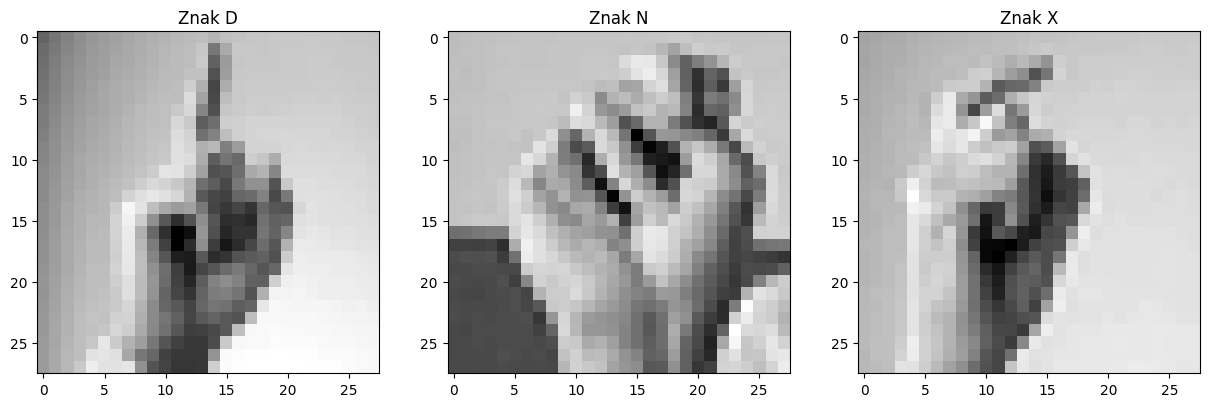

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(X_train[0], cmap="gray")
axs[0].set_title(f"Znak {get_label(y_train, 0)}")

axs[1].imshow(X_train[1000], cmap="gray")
axs[1].set_title(f"Znak {get_label(y_train, 1000)}")

axs[2].imshow(X_train[10000], cmap="gray")
axs[2].set_title(f"Znak {get_label(y_train, 10000)}");

### Model klasifikacije

Kreirati ćemo model klasifikacije slika znakova znakovnog jezika. Upakirati ćemo ga u funkciju kako bi olakšali daljnje korištenje.

In [10]:
def classification(images, labels, val_images, val_labels, epochs_num=5):
    model = models.Sequential([
        tf.keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(25, activation="softmax")
    ])

    model.compile(optimizer="adam",
                loss="sparse_categorical_crossentropy",
                metrics=["sparse_categorical_accuracy"])

    model.fit(images, labels, epochs=epochs_num, batch_size=32, validation_data=(val_images, val_labels));

Primjer poziva funkcije klasifikacije.

In [11]:
classification(X_train, y_train, X_test, y_test)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 2.6649 - sparse_categorical_accuracy: 0.5985 - val_loss: 0.5518 - val_sparse_categorical_accuracy: 0.8514
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0129 - sparse_categorical_accuracy: 0.9970 - val_loss: 0.6431 - val_sparse_categorical_accuracy: 0.8324
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0255 - sparse_categorical_accuracy: 0.9917 - val_loss: 0.5248 - val_sparse_categorical_accuracy: 0.9023
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2.4975e-04 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.5379 - val_sparse_categorical_accuracy: 0.9045
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 6.3484e-05 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.5398 - val_sparse_categorical_accuracy: 0.9048
